In [22]:
import numpy as np
import yaml
import pprint
from pathlib import Path
import random
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torch.nn import MSELoss
from torch.optim import Adam
from torch import nn
import matplotlib.pyplot as plt

In [23]:
TRAIN_SET_PATH = "/opt/shared/datasets/NeoRadiumTDLdataset/train/TDLA"
LIMIT_DATA_SIZE = 1000
TRAIN_SNR_LEVELS = [0, 10, 20, 30]
SNR_LEVELS = [0, 5, 10, 15, 20, 25, 30]

In [24]:
def plot_magnitude_phase(h, title="h_true", figsize=(10, 5)):
    """Plot magnitude and phase of a channel as 2D: subcarriers vs time (symbol) indices."""
    h = np.asarray(h, dtype=complex)
    if h.ndim != 2:
        raise ValueError("h must be 2D (subcarriers x symbols).")
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    plt.imshow(np.abs(h), aspect="auto", origin="lower")
    plt.xlabel("Symbol / time index")
    plt.ylabel("Subcarrier index")
    plt.title(f"Magnitude of {title}")
    plt.colorbar()
    plt.subplot(1, 2, 2)
    plt.imshow(np.angle(h), aspect="auto", origin="lower")
    plt.xlabel("Symbol / time index")
    plt.ylabel("Subcarrier index")
    plt.title(f"Phase of {title}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [25]:
class TDLDataset(Dataset):
    def __init__(
        self, data_path, *, file_size, normalization_stats=None,return_pilots_only=True, num_subcarriers=120,
        num_symbols=14, SNRs=[0, 5, 10, 15, 20, 25, 30],
        pilot_symbols=[2, 11], pilot_every_n=2):
        """
        This class loads the data from the folder and returns a dataset of channels.

        data_path: path to the folder containing the data
        file_size: number of channels per file
        return_pilots_only: if True, only the LS channel estimate at pilots are returned
            if False, the LS channel estimate is returned as a sparse channel matrix with non-zero 
            values only at the pilot subcarriers and time instants.
        num_subcarriers: number of subcarriers
        num_symbols: number of OFDM symbols

        SNRs: list of SNR values to randomly sample from when return LS estimates.
            AWGN is added to simulate LS estimatation error
        pilot_symbols: list of OFDM symbol indices where pilots are placed
        pilot_every_n: number of subcarriers between pilot subcarriers
        """
        
        self.file_size = int(file_size)
        self.normalization_stats = normalization_stats
        self.return_pilots_only = return_pilots_only
        self.num_subcarriers = num_subcarriers
        self.num_symbols = num_symbols
        self.SNRs = SNRs
        self.pilot_symbols = pilot_symbols
        self.pilot_every_n = pilot_every_n

        self.file_list = list(Path(data_path).glob("*.npy"))
        self.stats = self._get_stats_per_file(self.file_list)
        self.data = self._load_data_from_folder(self.file_list, self.normalization_stats)
        self.pilot_mask = self._get_pilot_mask()

        self.num_pilot_symbols = len(self.pilot_symbols)
        self.num_pilot_subcarriers = int(self.pilot_mask.sum()) // self.num_pilot_symbols

    def __len__(self):
        return len(self.file_list) * self.file_size

    def __getitem__(self, idx):
        file_idx = idx // self.file_size
        sample_idx = idx % self.file_size
        file_path = self.file_list[file_idx]
        channels = self.data[file_path]
        channel = channels[sample_idx].squeeze().T
    
        SNR = random.choice(self.SNRs)
        LS_channel_at_pilots = self._get_LS_estimate_at_pilots(channel, SNR)
        stats = self.stats[file_path]
        stats["SNR"] = SNR

        LS_channel_at_pilots_torch = torch.from_numpy(LS_channel_at_pilots).to(torch.complex64)
        channel_torch = torch.from_numpy(channel).to(torch.complex64)
        return LS_channel_at_pilots_torch, channel_torch, stats
    
    @staticmethod
    def _load_data_from_folder(file_list, normalization_stats=None):
        data = {}
        for file_path in file_list:
            file_data = np.load(file_path)
            if normalization_stats is not None:
                normalized_real = (file_data.real - normalization_stats["real_mean"]) / normalization_stats["real_std"]
                normalized_imag = (file_data.imag - normalization_stats["imag_mean"]) / normalization_stats["imag_std"]
                file_data = normalized_real + 1j * normalized_imag
            data[file_path] = file_data
        return data

    @staticmethod
    def _get_stats_per_file(file_list):
        stats = {}

        for file_path in file_list:
            file_name = str(file_path.stem)
            file_parts = file_name.split("_")

            if file_parts[0] == "delay":
                delay_spread = int(file_parts[2])  # [delay, spread, y, doppler, x]
                doppler_shift = int(file_parts[-1])
            elif file_parts[0] == "doppler":
                doppler_shift = int(file_parts[1])  # [doppler, x, delay, spread, y]
                delay_spread = int(file_parts[-1])
            else:
                raise ValueError(f"File {file_name} has unexpected format")
            
            if file_path not in stats:
                stats[file_path] = {"doppler_shift": doppler_shift, "delay_spread": delay_spread}
            else:
                raise ValueError(f"File {file_path} already in stats, but should not be")
            
        return stats
    
    def _get_LS_estimate_at_pilots(self, channel_matrix, SNR):
        # unit symbol power and unit channel power --> rx noise var = LS error var
        noise_std = np.sqrt(1 / (10**(SNR / 10)))
        noise_real_imag = noise_std / np.sqrt(2)

        if self.return_pilots_only:
            pilot_mask_bool = self.pilot_mask.astype(bool)
            channel_at_pilots = channel_matrix[pilot_mask_bool]
            channel_at_pilots = channel_at_pilots.reshape(self.num_pilot_subcarriers, self.num_pilot_symbols)
            noise_real = noise_real_imag * np.random.randn(self.num_pilot_subcarriers, self.num_pilot_symbols)
            noise_imag = noise_real_imag * np.random.randn(self.num_pilot_subcarriers, self.num_pilot_symbols)
            noise = noise_real + 1j * noise_imag
        else:
            channel_at_pilots = self.pilot_mask * channel_matrix
            noise_real = noise_real_imag * np.random.randn(self.num_subcarriers, self.num_symbols)
            noise_imag = noise_real_imag * np.random.randn(self.num_subcarriers, self.num_symbols)
            noise = noise_real + 1j * noise_imag
            noise = noise * self.pilot_mask
        
        channel_at_pilots_LS = channel_at_pilots + noise
            
        return channel_at_pilots_LS

    def _get_pilot_mask(self):
        pilot_mask = np.zeros((self.num_subcarriers, self.num_symbols))
        pilot_mask_subcarrier_indices = np.arange(0, self.num_subcarriers, self.pilot_every_n)
        pilot_mask[np.ix_(pilot_mask_subcarrier_indices, self.pilot_symbols)] = 1
        return pilot_mask
        

In [26]:
file_list = list(Path(TRAIN_SET_PATH).glob("*.npy"))

print("There are", len(file_list), "files in the dataset")

channel_power_list = []
for file in file_list:
    data = np.load(file).squeeze()
    channel_power_list.append(np.mean(np.abs(data)**2))

avg_channel_power = np.array(channel_power_list).mean()
print("Average channel power:", avg_channel_power)
assert avg_channel_power == 1,  "Channels are not normalized to unit power!"

There are 240 files in the dataset
Average channel power: 1.0


In [27]:
with open(Path(TRAIN_SET_PATH, "metadata.yaml"), "r") as f:
    train_metadata = yaml.safe_load(f)

large_dataset = TDLDataset(
    TRAIN_SET_PATH, 
    file_size=train_metadata["config"]["num_channels_per_config"],
    SNRs=SNR_LEVELS,
    return_pilots_only=True)

small_dataset_indices = np.random.choice(len(large_dataset), size=LIMIT_DATA_SIZE, replace=False)

small_dataset = Subset(large_dataset, small_dataset_indices)

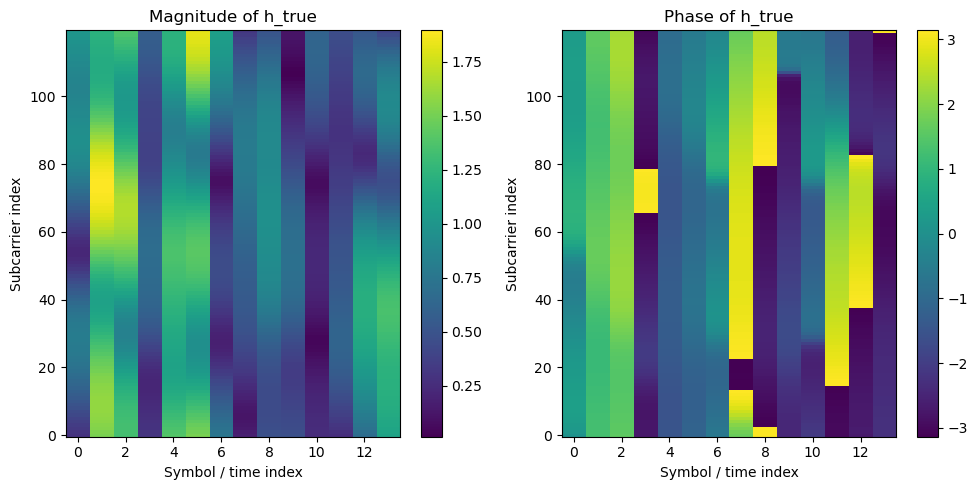

In [28]:
sample_idx = 0
h_true = small_dataset[sample_idx][1]
plot_magnitude_phase(h_true)
